In [1]:
!pip install pandas


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
data = pd.read_excel(r"D:\Docus\Minor-Internship-project\notebooks\data\raw\Supermart Grocery Sales - Retail Analytics Dataset.xlsx")

In [4]:
data.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11 00:00:00,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11 00:00:00,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06 00:00:00,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-11-10 00:00:00,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-11-10 00:00:00,South,2355,0.26,918.45,Tamil Nadu


In [5]:
data.isna().sum()


Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


In [7]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [8]:
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Month Name'] = data['Order Date'].dt.month_name()
data['Profit Margin %'] = (data['Profit']*100/(data['Sales']-data['Discount'])).round(2)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         9994 non-null   object        
 1   Customer Name    9994 non-null   object        
 2   Category         9994 non-null   object        
 3   Sub Category     9994 non-null   object        
 4   City             9994 non-null   object        
 5   Order Date       9994 non-null   datetime64[ns]
 6   Region           9994 non-null   object        
 7   Sales            9994 non-null   int64         
 8   Discount         9994 non-null   float64       
 9   Profit           9994 non-null   float64       
 10  State            9994 non-null   object        
 11  Year             9994 non-null   int32         
 12  Month            9994 non-null   int32         
 13  Month Name       9994 non-null   object        
 14  Profit Margin %  9994 non-null   float64

In [10]:
data.head(3)

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Year,Month,Month Name,Profit Margin %
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,2017,8,August,32.0
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,2017,8,August,20.0
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,2017,12,December,7.0


In [11]:
Total_sales = data['Sales'].sum()
Total_sales

np.int64(14956982)

In [12]:
Total_orders = data['Order ID'].nunique()
Total_orders

9994

In [13]:
Total_profit = data['Profit'].sum()
Total_profit

np.float64(3747121.1999999997)

In [14]:
Profit_margin = data['Profit Margin %']
Profit_margin

0       32.00
1       20.00
2        7.00
3       10.00
4       39.00
        ...  
9989    38.01
9990     6.00
9991    32.00
9992    36.00
9993    16.00
Name: Profit Margin %, Length: 9994, dtype: float64

In [15]:
Avg_order_value = Total_sales / Total_orders
Avg_order_value

np.float64(1496.5961576946167)

In [16]:
kpi_data = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Total Orders',
        'Total Profit',
        'Average Order Value',
         
        
    ],
    'Value': [
        Total_sales,
        Total_orders,
        Total_profit,
        Avg_order_value,
       
    ]
})

kpi_data 

,KPI,Value
0,Total Sales,1.495698e+07
1,Total Orders,9.994000e+03
2,Total Profit,3.747121e+06
3,Average Order Value,1.496596e+03


In [17]:
import matplotlib.pyplot as plt

In [18]:
sales_by_year = data.groupby('Year')['Sales'].sum()
sales_by_year

Year
2015    2975599
2016    3131959
2017    3871912
2018    4977512
Name: Sales, dtype: int64

<h2>Graphs

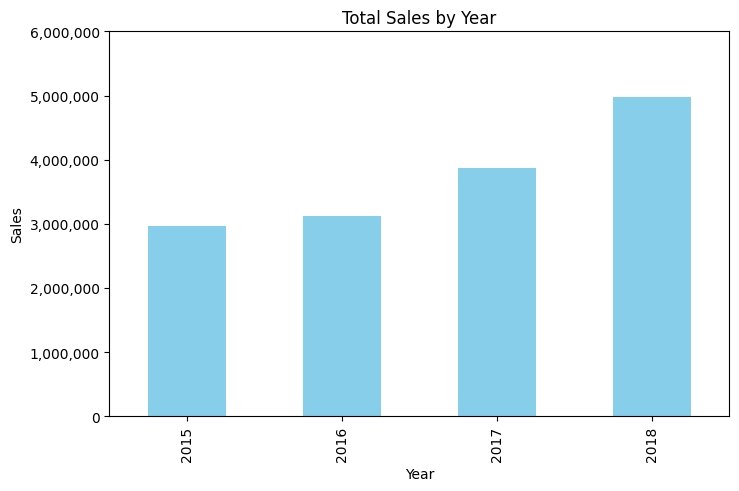

In [19]:
sales_by_year.plot(kind='bar', figsize=(8,5), title='Total Sales by Year', color='skyblue')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.ylabel('Sales')
plt.ylim(0, 6000000)
plt.show()

In [20]:
reindexed_month_name=['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

In [21]:
sales_by_month = data.groupby('Month Name')['Sales'].sum().reindex(reindexed_month_name)
sales_by_month

Month Name
January       902128
February      830301
March        1247196
April        1028352
May          1251327
June         1028694
July         1107483
August       1220430
September    1706141
October      1237389
November     1794831
December     1602710
Name: Sales, dtype: int64

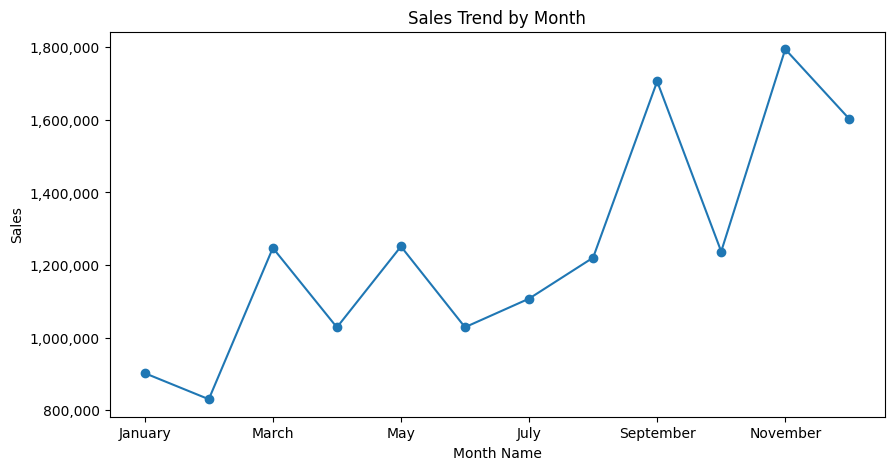

In [22]:
sales_by_month.plot(kind='line', figsize=(10,5), marker='o', title='Sales Trend by Month')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
plt.ylabel('Sales')
plt.show()

In [23]:
data.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State', 'Year',
       'Month', 'Month Name', 'Profit Margin %'],
      dtype='object')

In [24]:
sales_by_sub_category = data.groupby('Sub Category')['Sales'].sum()
sales_by_sub_category

Sub Category
Atta & Flour           534649
Biscuits               684083
Breads & Buns          742586
Cakes                  685612
Chicken                520497
Chocolates             733898
Cookies                768213
Dals & Pulses          523371
Edible Oil & Ghee      668086
Eggs                   575156
Fish                   560548
Fresh Fruits           551212
Fresh Vegetables       525842
Health Drinks         1051439
Masalas                697480
Mutton                 611200
Noodles                735435
Organic Fruits         503402
Organic Staples        558929
Organic Vegetables     520271
Rice                   498323
Soft Drinks           1033874
Spices                 672876
Name: Sales, dtype: int64

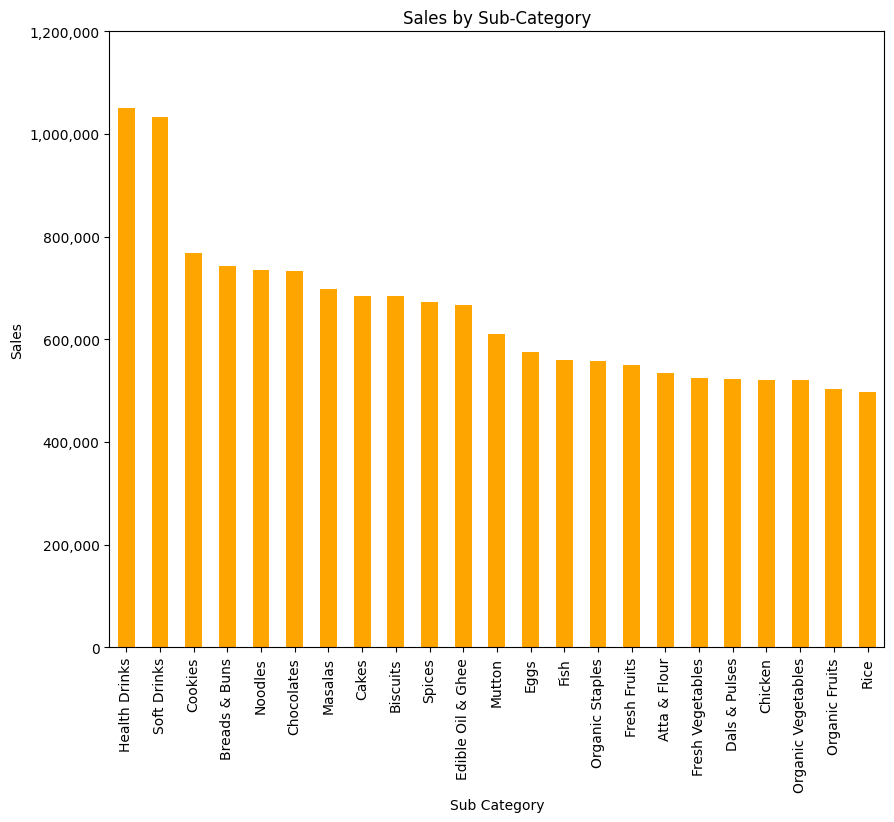

In [25]:
data.groupby('Sub Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10,8), title='Sales by Sub-Category', color='orange')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter( lambda x, p: f'{int(x):,}'))
plt.ylabel('Sales')
plt.ylim(0, 1200000)
plt.show()

In [26]:
sales_by_region = data.groupby('Region')['Sales'].sum()
sales_by_region

Region
Central    3468156
East       4248368
North         1254
South      2440461
West       4798743
Name: Sales, dtype: int64

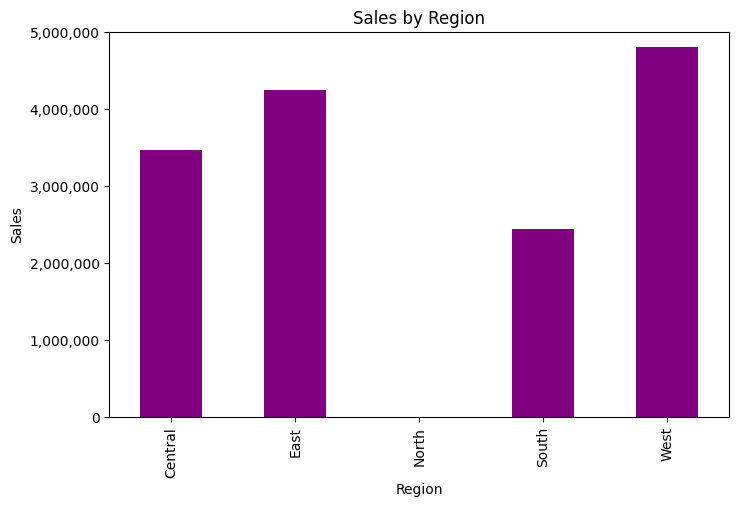

In [27]:
data.groupby('Region')['Sales'].sum().plot(kind='bar', figsize=(8,5), title='Sales by Region', color='purple')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter( lambda x, p: f'{int(x):,}'))
plt.ylabel('Sales')
plt.ylim(0, 5000000)
plt.show() ##north's sale is less than 50k , thus it appears to be empty on a scale of 5 million.

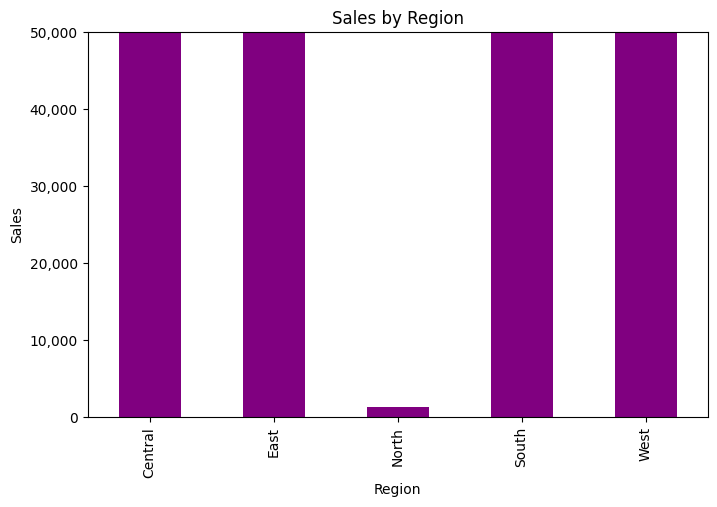

In [38]:
data.groupby('Region')['Sales'].sum().plot(kind='bar', figsize=(8,5), title='Sales by Region', color='purple')
plt.ticklabel_format(style='plain', axis='y')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter( lambda x, p: f'{int(x):,}'))
plt.ylabel('Sales')
plt.ylim(0, 50000)
plt.show()

In [28]:
data.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State', 'Year',
       'Month', 'Month Name', 'Profit Margin %'],
      dtype='object')

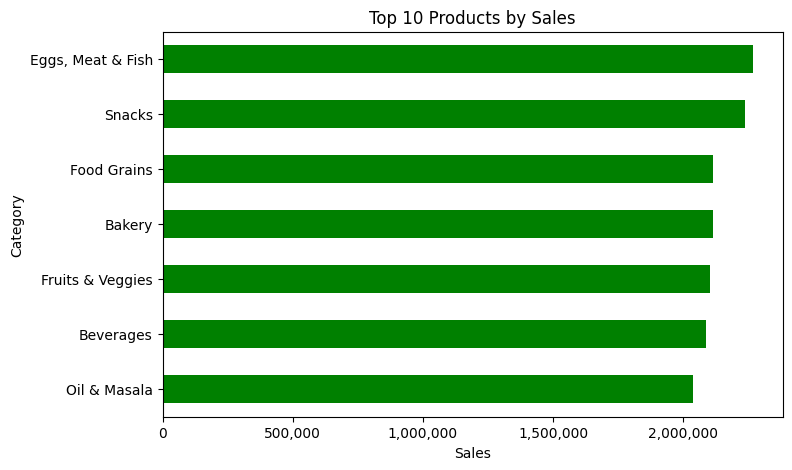

In [29]:
top_products = data.groupby('Category')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(8,5), color='green', title='Top 10 Products by Sales')
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter( lambda x, p: f'{int(x):,}'))
plt.xlabel('Sales')
plt.gca().invert_yaxis()
plt.show()

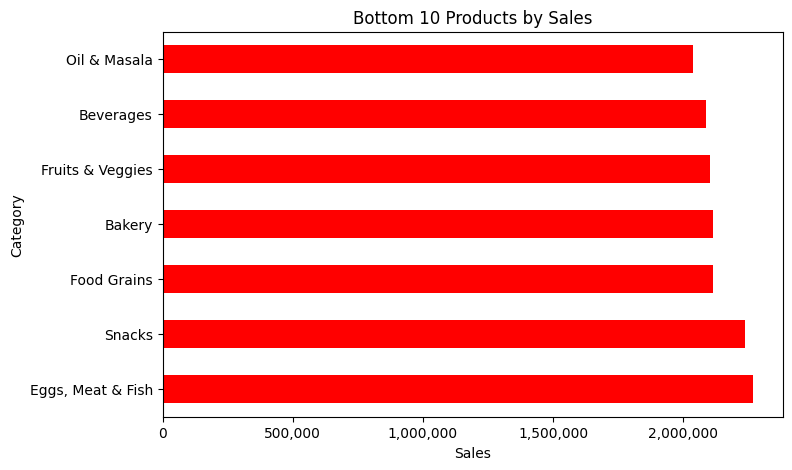

In [30]:
bottom_products = data.groupby('Category')['Sales'].sum().sort_values(ascending=True).head(10)
graph = bottom_products.plot(kind='barh', figsize=(8,5), color='red', title='Bottom 10 Products by Sales')
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter( lambda x, p: f'{int(x):,}'))
plt.xlabel('Sales')
graph.invert_yaxis()
plt.show()

<h2>Linear regression Model

In [31]:
data.columns

Index(['Order ID', 'Customer Name', 'Category', 'Sub Category', 'City',
       'Order Date', 'Region', 'Sales', 'Discount', 'Profit', 'State', 'Year',
       'Month', 'Month Name', 'Profit Margin %'],
      dtype='object')

In [32]:
correlation = data[['Sales', 'Discount', 'Profit', 'Month', 'Profit Margin %']].corr()['Profit'].sort_values(ascending=False)
print(correlation)

Profit             1.000000
Profit Margin %    0.747139
Sales              0.605349
Discount           0.000017
Month             -0.014923
Name: Profit, dtype: float64


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_absolute_error

# Encode categorical variables for converting into float to compare their relation with profit
le_category = LabelEncoder()
le_region = LabelEncoder()

data['Category_encoded'] = le_category.fit_transform(data['Category'])
data['Region_encoded'] = le_region.fit_transform(data['Region'])

# Create feature matrix and target vector
features = ['Sales', 'Profit Margin %', 'Discount', 'Category_encoded', 'Region_encoded']
X = data[features].copy()
y = data['Profit']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())
print("\nFeature data types:")
print(X.dtypes)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)


# Predict
y_train_pred = model.predict(X_train)  # predictions on training set
y_test_pred = model.predict(X_test)    # predictions on test set

# Evaluate
mae_value = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Train R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")
print(f"Mean_Absolute_Error: ${mae_value:.2f}")
print(f"RMSE: ${rmse:.2f}")

# Simple overfitting check
if r2_train - r2_test > 0.05:
    print("⚠️ Model may be overfitting")
else:
    print("✅ Model generalizes well")

Features (X):
   Sales  Profit Margin %  Discount  Category_encoded  Region_encoded
0   1254             32.0      0.12                 5               2
1    749             20.0      0.18                 1               3
2   2360              7.0      0.21                 3               4
3    896             10.0      0.25                 4               3
4   2355             39.0      0.26                 3               3

Target (y):
0    401.28
1    149.80
2    165.20
3     89.60
4    918.45
Name: Profit, dtype: float64

Feature data types:
Sales                 int64
Profit Margin %     float64
Discount            float64
Category_encoded      int64
Region_encoded        int64
dtype: object
Train R²: 0.9187
Test R²: 0.9204
Mean_Absolute_Error: $51.71
RMSE: $68.97
✅ Model generalizes well
